# Session 5 - Regulizers(L1,L2,L1-L2) - SGD : Hyperparameter : warm start - penalty - tol - n_iter_no_change - early stopping- 

In [304]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error,root_mean_squared_error

## Regulizer - L1(Lasso) - L2( Ridge) - L1-L2 (Elastic) 

In [28]:
from sklearn.linear_model import SGDRegressor

model = SGDRegressor(
    learning_rate = 'constant',
    eta0 = 0.01,
    alpha = 0.5,
    fit_intercept = True,
    penalty= 'L1',
    max_iter = 100,
    warm_start = True,
    early_stopping= True,
    tol= 0.00001,
    n_iter_no_change = 5,
)
# Cost = MSE + alpha × Penalty - 
# intercept: True (default):    y = b + aX False y= aX



# or use :
from sklearn.linear_model import Lasso , Ridge
# do not need GD so lr max_iter and etc

model_2 = Lasso(
    alpha=0.5,              # Regularization strength
    fit_intercept=True,     # Add bias
    max_iter=1000,          # Max iterations
    tol=0.0001,             # Tolerance
    warm_start=True         # Reuse solution
)


model_3 = Ridge(
    alpha=0.5,
    fit_intercept=True,
    max_iter=1000,
    tol=0.0001
)



## Implementing Regulizer ON BTC data

In [45]:
df = pd.read_csv("bitcoin2026.csv")
#print(df)
df.shape
df

# add the price of tomorrow how:
df["TomorrowClose"] = df["Close"].shift(-1)
df
# the last row has nan so drop it:
df.dropna(inplace=True)
df

,Date,Close,High,Low,Open,Volume,TomorrowClose
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,424.440002
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,394.795990
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,408.903992
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,398.821014
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,402.152008
...,...,...,...,...,...,...,...
4249,2026-05-06,81427.531250,82792.210938,80751.023438,80930.734375,41751540000,80009.992188
4250,2026-05-07,80009.992188,81684.953125,79522.656250,81428.851562,36931193154,80186.765625
4251,2026-05-08,80186.765625,80447.265625,79205.515625,80009.625000,33789351540,80664.367188
4252,2026-05-09,80664.367188,81030.062500,80119.929688,80187.742188,18102086996,82138.929688


In [234]:
# Build a model to predict the price of tomorrow close based on some features from last days:
X = df[["Open",'High','Low',"Close"]] #suppose
y = df['TomorrowClose']

X.shape
y.shape

(4254,)

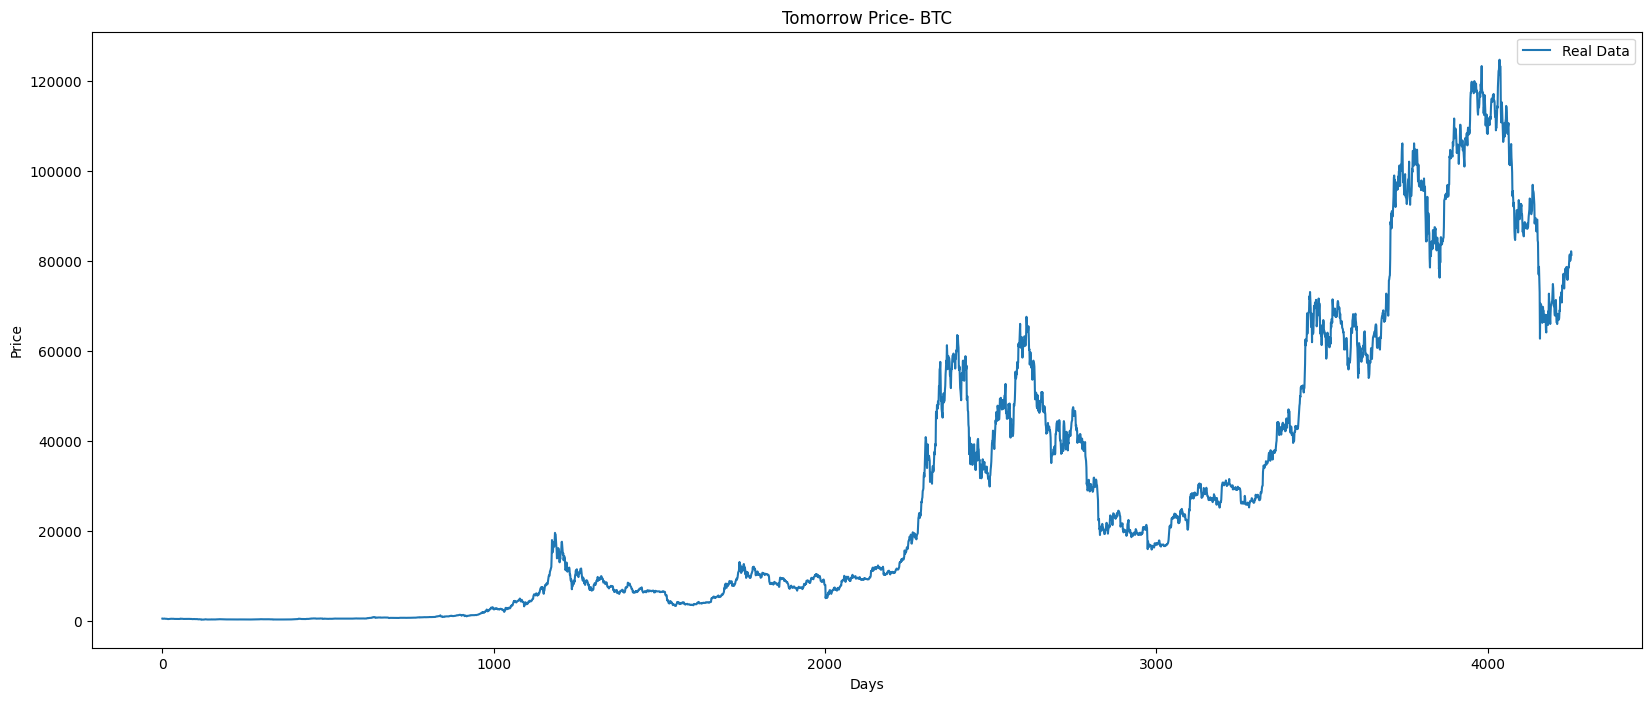

In [235]:
# Visualize the Tomorrow price:
plt.figure(figsize=(20,8))
plt.plot(y , label="Real Data")
plt.title("Tomorrow Price- BTC")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()

In [236]:
# Split data to train and test - then visualize
X_train,X_test,y_train,y_test= train_test_split(X,y,train_size = 0.85,shuffle= False)
# Fasle cause is time_series

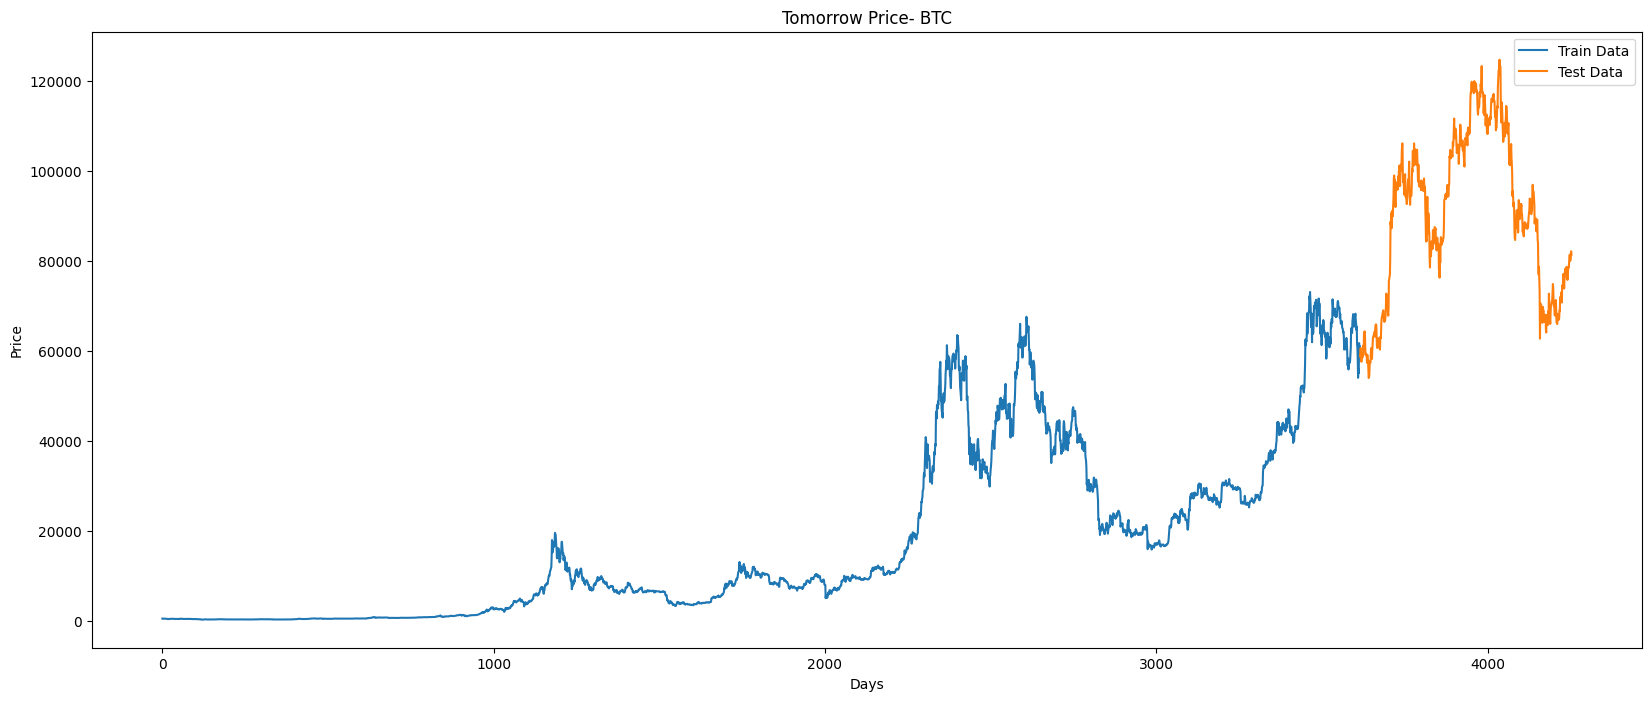

In [237]:
#Visualize:
plt.figure(figsize=(20,8))

plt.plot(y_train, label="Train Data")

plt.plot(y_test, label = "Test Data")
plt.title("Tomorrow Price- BTC")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()

### USING Ridge

In [ ]:
model = SGDRegressor(
    loss = "squared_error",
    learning_rate = 'constant',
    eta0 = 0.01,
    alpha = 0.5,
    fit_intercept = True,
    penalty= 'l2',
    max_iter = 100,
    #warm_start = True,
    early_stopping= True,
    tol= 0.000001,
    n_iter_no_change = 5,
    verbose=True
)

In [261]:
model.fit(X_train,y_train)

-- Epoch 1
Norm: 186278875583375.94, NNZs: 4, Bias: -290000493865.417664, T: 3253, Avg. loss: 331011334613642896906456054486433529856.000000
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 34283296756845.18, NNZs: 4, Bias: 319999506134.582336, T: 6506, Avg. loss: 315675566293837697031036923692852445184.000000
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 549742018559395.56, NNZs: 4, Bias: 349999506134.582275, T: 9759, Avg. loss: 327895017657282974414145600195659825152.000000
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 114437676515503.11, NNZs: 4, Bias: 599999506134.582275, T: 13012, Avg. loss: 341280053176401997453808415532774326272.000000
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 128981437361147.78, NNZs: 4, Bias: 69999506134.582275, T: 16265, Avg. loss: 340791175301515255662578775657921118208.000000
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 559687877562100.38, NNZs: 4, Bias: -60000493865.417725, T: 19518, Avg. loss: 328833601324972006887002514121

,loss,'squared_error'
,penalty,'l2'
,alpha,0.5
,l1_ratio,0.15
,fit_intercept,True
,max_iter,100
,tol,1e-06
,shuffle,True
,verbose,True
,epsilon,0.1
,random_state,None


In [262]:
# see if there is overfiting how: comparing the mse on y-pred-traind and y-pred-test
y_pred_train = model.predict(X_train)
train_mse =  mean_squared_error(y_train,y_pred_train)

y_pred_test = model.predict(X_test)
test_mse = mean_squared_error(y_test,y_pred_test)

print(train_mse)
print(test_mse)
#  difference ----> so maybe OVERFIT 

X_train

8.227717766753155e+38
1.0426806136771461e+40


,Open,High,Low,Close
0,465.864014,468.174011,452.421997,457.334015
1,456.859985,456.859985,413.104004,424.440002
2,424.102997,427.834991,384.532013,394.795990
3,394.673004,423.295990,389.882996,408.903992
4,408.084991,412.425995,393.181000,398.821014
...,...,...,...,...
3610,58110.296875,58268.828125,49121.238281,53991.457031
3611,53991.347656,57059.917969,53973.273438,56034.316406
3612,56040.632812,57726.882812,54620.507812,55027.460938
3613,55030.027344,62673.765625,54766.726562,61710.136719


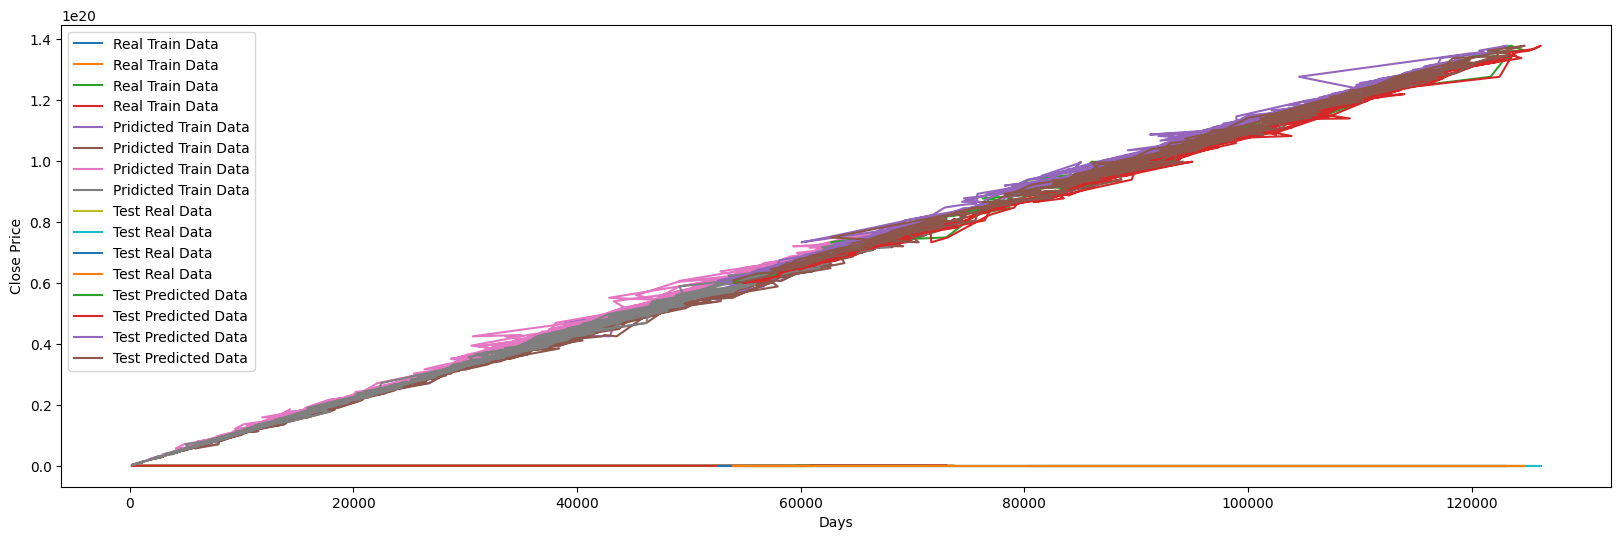

In [263]:
#Visualization: 
plt.figure(figsize=(20,6))

plt.plot(X_train,y_train,label = "Real Train Data")
plt.plot(X_train,y_pred_train, label = "Pridicted Train Data" )


plt.plot(X_test,y_test, label="Test Real Data")
plt.plot(X_test,y_pred_test, label="Test Predicted Data")

plt.xlabel("Days")
plt.ylabel("Close Price")
plt.legend()


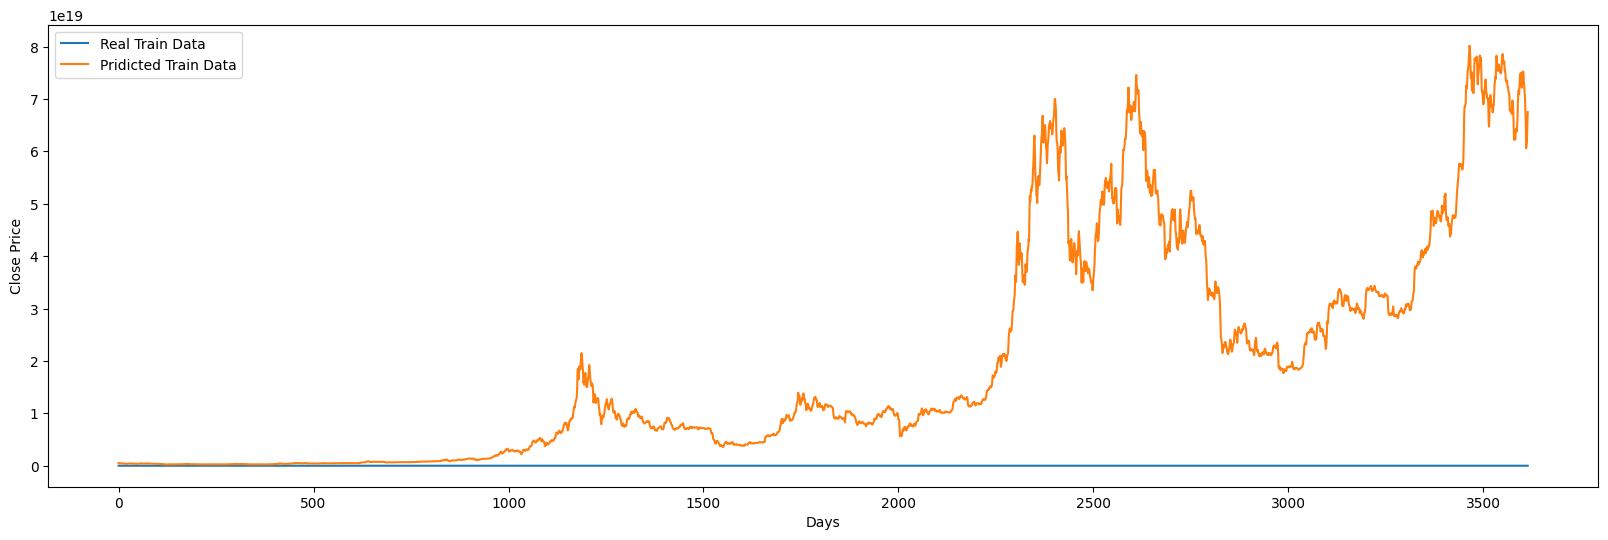

In [264]:
#Visualization
#Visualization: 
plt.figure(figsize=(20,6))

plt.plot(y_train,label = "Real Train Data")
plt.plot(y_pred_train, label = "Pridicted Train Data" )


#plt.plot(y_test, label="Test Real Data")
#plt.plot(y_pred_test, label="Test Predicted Data")

plt.xlabel("Days")
plt.ylabel("Close Price")
plt.legend()


#Underfitted Model ( even cannot learn train data) - You used Ridge (L2)

In [266]:
# lets have a better point of view on the difference price it take: get real price
# Close Price Real
df["TomorrowClose"].iloc[-1] #81358.0

# fisrt take the features of the last day to pridect you need:
df[["Open", "Low", "High", "Close"]].iloc[-1] 
#Open     80665.609375
 #Low      80274.132812
 #High     82430.171875
 #Close    82138.929688

new_X = [[80665.609375 , 80274.1328125, 82430.171875,  82138.9296875]]
model.predict(new_X)
# pridected price : 9.02032021e+19
#real price:        81358.0
#فاجعه

C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SGDRegressor was fitted with feature names
  warnings.warn(


array([9.02032021e+19])

### Using Lasso 


In [ ]:
model = Lasso()
model.fit(X_train, y_train)

In [268]:
y_pred_train = model.predict(X_train)
train_mse =  mean_squared_error(y_train,y_pred_train)

y_pred_test = model.predict(X_test)
test_mse = mean_squared_error(y_test,y_pred_test)

print(train_mse)
print(test_mse)

#beaware the BTC is huge price so this is not that much diifer 

821228.3797700532
4520855.985306844


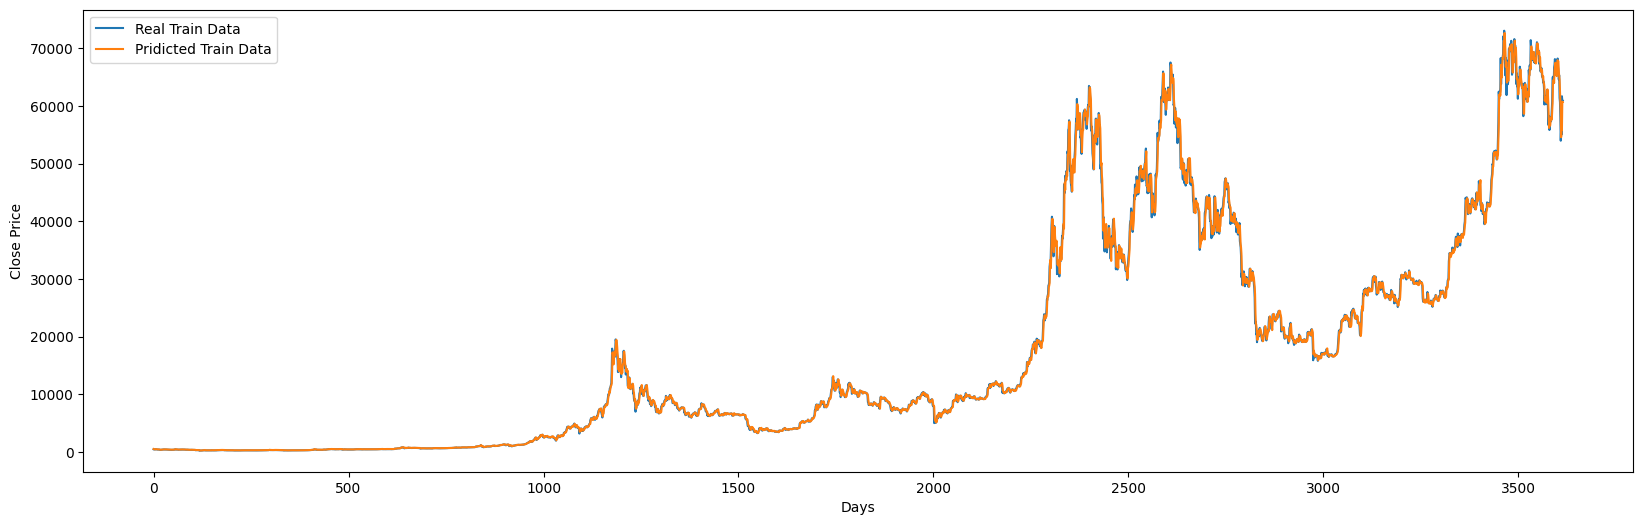

In [269]:
plt.figure(figsize=(20,6))

plt.plot(y_train,label = "Real Train Data")
plt.plot(y_pred_train, label = "Pridicted Train Data" )


#plt.plot(y_test, label="Test Real Data")
#plt.plot(y_pred_test, label="Test Predicted Data")

plt.xlabel("Days")
plt.ylabel("Close Price")
plt.legend()

#Overfitted model : learnt train data but mse between train and test is huge :Error ratio: 2-7% of price → NOT terrible!

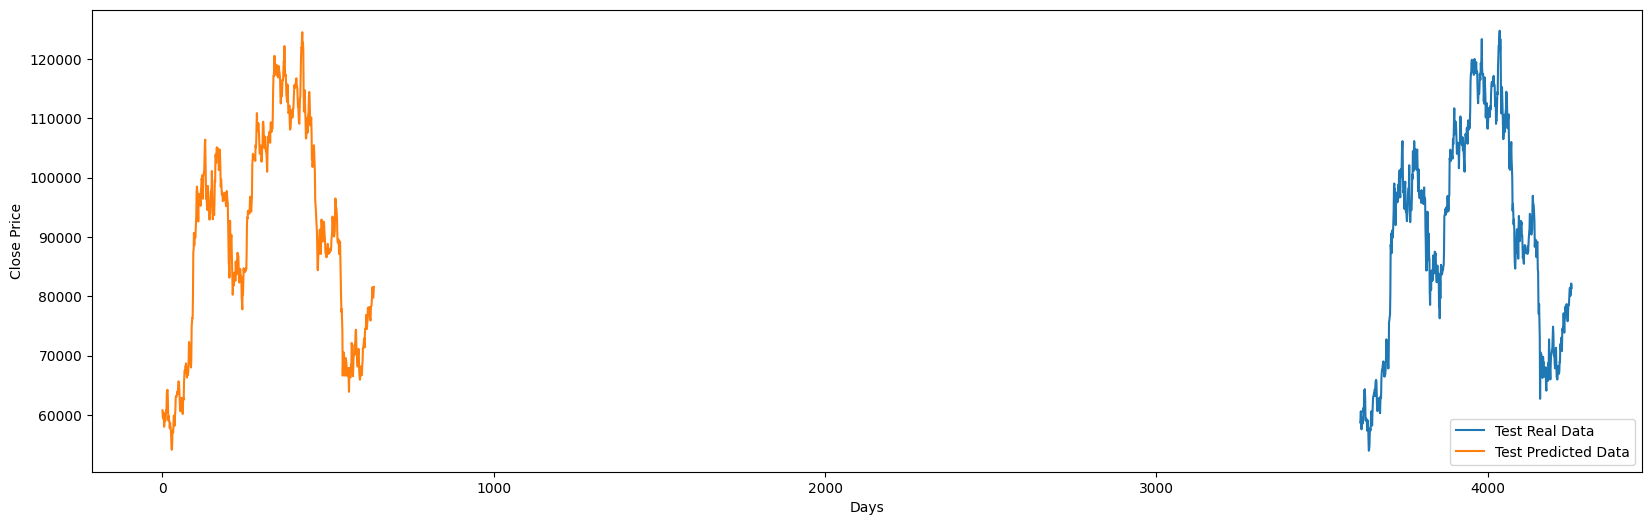

In [270]:
plt.figure(figsize=(20,6))

#plt.plot(y_train,label = "Real Train Data")
#plt.plot(y_pred_train, label = "Pridicted Train Data" )


plt.plot(y_test, label="Test Real Data")
plt.plot(y_pred_test, label="Test Predicted Data")

plt.xlabel("Days")
plt.ylabel("Close Price")
plt.legend()


In [271]:
# lets have a better point of view on the difference price it take: get real price
# Close Price Real
df["TomorrowClose"].iloc[-1] #81358.0

# fisrt take the features of the last day to pridect you need:
df[["Open", "Low", "High", "Close"]].iloc[-1] 
#Open     80665.609375
 #Low      80274.132812
 #High     82430.171875
 #Close    82138.929688

new_X = [[80665.609375 , 80274.1328125, 82430.171875,  82138.9296875]]
model.predict(new_X)
# pridected price : 81011.70340736
#real price:        81358.0
#NOT that BAD

C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


array([81011.70340736])

#### Cost function for train mse and test mse for compare

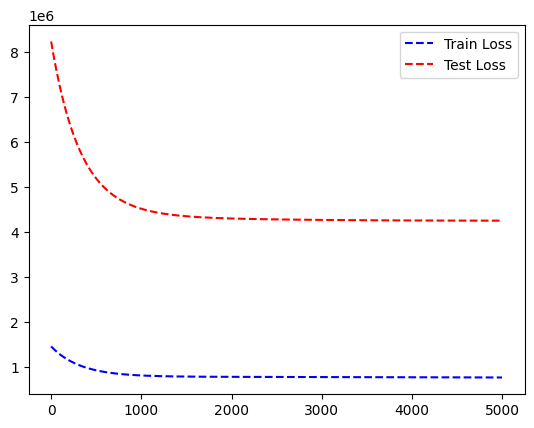

In [284]:
# tricky way here is using warm_start =true to can show each step tjat model learn at the sime time show the mse test

import warnings
warnings.filterwarnings('ignore')  # ← Add at the very top

model = Lasso (max_iter= 1,warm_start=True)

train_cost_function = []
test_cost_function= []

for i in range(5000):
    #train 
    model.fit(X_train,y_train)
    y_pred_train = model.predict(X_train)
    mse_train =mean_squared_error(y_train,y_pred_train)
    train_cost_function.append(mse_train)

    #test
    y_pred_test = model.predict(X_test)
    mse_test =mean_squared_error(y_test,y_pred_test)
    test_cost_function.append(mse_test)

plt.plot(train_cost_function, 'b--' , label = "Train Loss")
plt.plot(test_cost_function, 'r--', label = "Test Loss")
plt.legend()
plt.show()
    

### USING Polynomial ON BTC DATA

In [ ]:
#higher polynomial degree = more wiggly curve = more overfitting risk!

#Low degree  → Underfit (can't capture pattern)
#Mid degree  → Good fit (captures trend, ignores noise)
#High degree → Overfit (fits every noise point perfectly)

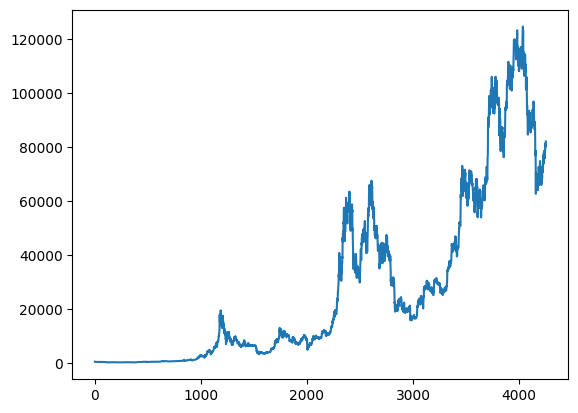

In [287]:
X = np.arange(len(df))  # number of row = days = X
y = df["Close"]
plt.plot(X,y)

In [290]:
# np has np.polyfit it gives you the parameters - degrees = 1,2,...
np.polyfit(X,y,1) #: array([  b:  22.29557189, a:-19056.91402696]) a X +b
np.polyfit(X,y,2) #array([ b: 7.76014763e-03, a1: -1.07083360e+01, a2: 4.33185535e+03])
#a1X + a2X^2 + B

#np.poly1d(np.polyfit()) this gives you the equation - function for build model use this
np.poly1d(np.polyfit(X,y,1))

poly1d([    22.29557189, -19056.91402696])

Text(0.5, 1.0, 'Polynomial degree 10 on BTC ')

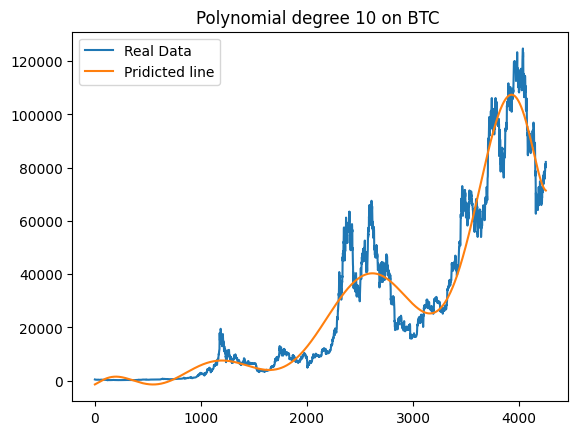

In [324]:
model = np.poly1d(np.polyfit(X,y,10))
pred= model(X)

plt.plot(X,y,label='Real Data')
plt.plot(X,pred, label="Pridicted line")
plt.legend()
plt.title("Polynomial degree 10 on BTC ")

In [298]:
# Random split
X_train = X[:3900]
y_train = y[:3900]

X_test = X[3900:]
y_test = y[3900:]

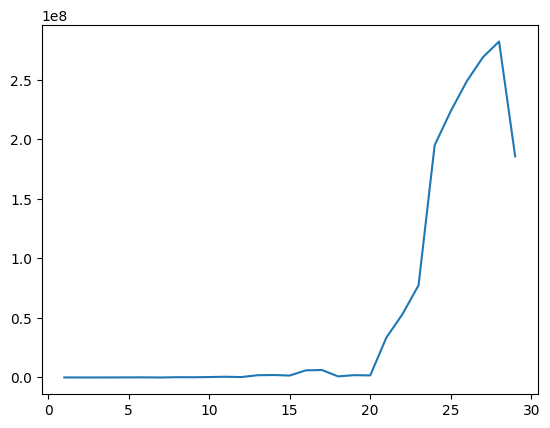

In [305]:
# find the best degree - less mse

degrees = []
for i in range (1,30):
    model = np.poly1d(np.polyfit(X_train,y_train, i))
    y_pred = model(X_test)
    degrees.append(root_mean_squared_error(y_test,y_pred))
plt.plot(range(1,30),degrees)    

#above 20 is bad

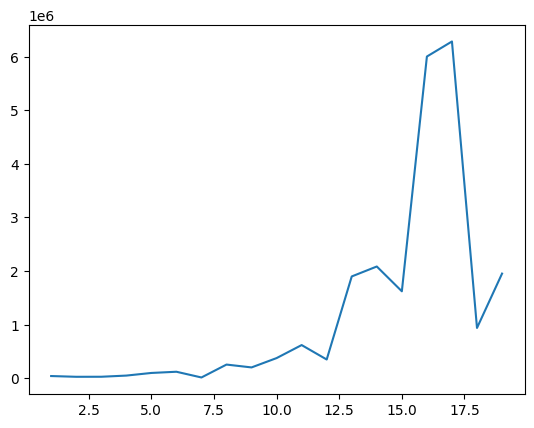

In [306]:
degrees = []
for i in range (1,20):
    model = np.poly1d(np.polyfit(X_train,y_train, i))
    y_pred = model(X_test)
    degrees.append(root_mean_squared_error(y_test,y_pred))
plt.plot(range(1,20),degrees)   

#above 11 is bad

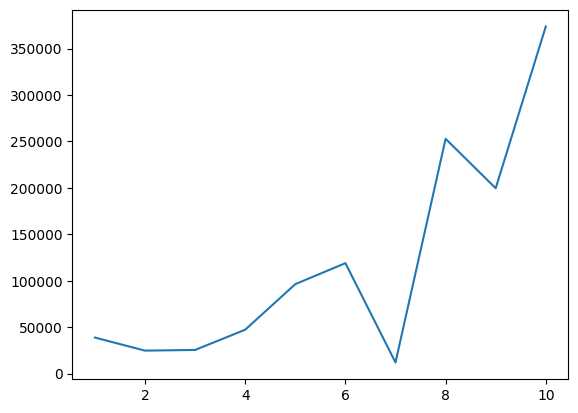

In [308]:
degrees = []
for i in range (1,11):
    model = np.poly1d(np.polyfit(X_train,y_train, i))
    y_pred = model(X_test)
    degrees.append(root_mean_squared_error(y_test,y_pred))
plt.plot(range(1,11),degrees)    


# 7 is the best

Text(0.5, 1.0, 'Polynomial (degree 7) on Test data (BTC)')

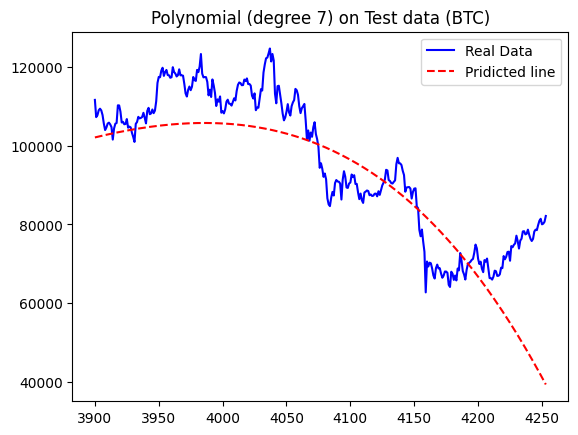

In [317]:
# Buil with best degree you found

model = np.poly1d(np.polyfit(X_train,y_train,7))
y_pred = model (X_test)

plt.plot(X_test,y_test,'b',label = 'Real Data')
plt.plot(X_test,y_pred,'r--',label = "Pridicted line")
plt.legend()
plt.title("Polynomial (degree 7) on Test data (BTC)")

# this show that it cannot pridict the test data correctly ( the price is upping our model says the price will be decreased


Text(0.5, 1.0, 'Polynomial (degree 7) on Train data (BTC)')

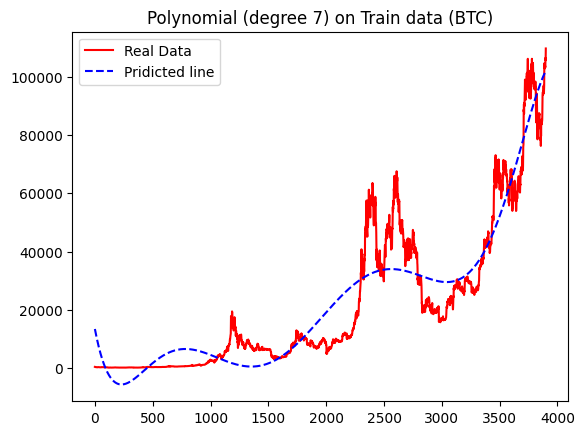

In [320]:
# On train data
y_pred_train= model (X_train)

plt.plot(X_train,y_train,'r',label="Real Data")
plt.plot(X_train,y_pred_train,'b--',label="Pridicted line")
plt.legend()
plt.title("Polynomial (degree 7) on Train data (BTC)")